In [3]:
import numpy as np
import matplotlib.pyplot as plt
from PINN_3d import *
from FFEM_building_blocks import Mesh
from scipy.sparse import csr_matrix
import matplotlib.pyplot as plt
from matplotlib.animation import FFMpegWriter, FuncAnimation
from scipy.sparse.linalg import spsolve

Mass matrix initialization completed
Stiffness matrix initialization completed


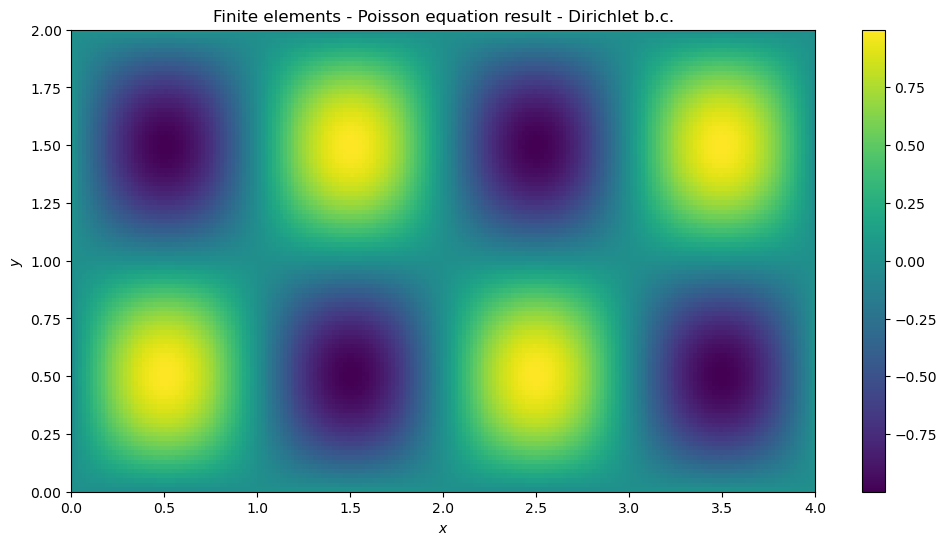

In [2]:
# As a reference solution, first compute the solution with the finite elements methods

x = np.linspace(0, 4, 200)
y = np.linspace(0, 2, 100)

mymesh = Mesh(x, y, verbose=True)
mymesh.build_mass_matrix()
mymesh.build_stiffness_matrix()

func = lambda x,y: 2.0 * np.pi**2 * np.sin(np.pi * x) * np.sin(np.pi * y)
diri = lambda x,y: 0
res_finite_elements = mymesh.run_simulation_poisson_dirichlet(func, diri)

plt.figure(figsize=(12, 6))
plt.imshow(res_finite_elements, cmap='viridis', origin='lower', aspect='auto', extent=[x.min(), x.max(), y.min(), y.max()]) # need origin "lower"
plt.colorbar()
plt.title('Finite elements - Poisson equation result - Dirichlet b.c.')
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.savefig('results/poisson.png')


In [3]:
# Example of a basic case for automatic differentiation with PyTorch (just for me to understand how to use PyTorch with a simple example)

x = torch.tensor(3.0, requires_grad=True)
y = x**2
y.backward()
# y.backward() saves the gradient back on x. Note that backward destryos the graph, so if I want to apply the graph another time I have to add retain_graph = True
print(x.grad)

tensor(6.)


In [4]:
f_poisson_torch = lambda x: 2.0 * torch.pi**2 * torch.sin(torch.pi * x[:, 0:1]) * torch.sin(torch.pi * x[:, 1:2])

trial_PINN = PINN_Poisson_2d(32, f_poisson_torch, lambda x: 0, (0,4), (0,2))
# attention, the Dirichlet and Poisson functions take lists [x, y] as inputs
trial_PINN.set_collocation_points(400)
trial_PINN.compute_boundary_values(100)

trial_PINN.train(30000)

Epoch [1000/30000], Loss: 0.0968
Epoch [2000/30000], Loss: 0.0634
Epoch [3000/30000], Loss: 0.0993
Epoch [4000/30000], Loss: 0.0480
Epoch [5000/30000], Loss: 0.0767
Epoch [6000/30000], Loss: 0.0122
Epoch [7000/30000], Loss: 0.0647
Epoch [8000/30000], Loss: 0.0122
Epoch [9000/30000], Loss: 0.0553
Epoch [10000/30000], Loss: 0.0059
Epoch [11000/30000], Loss: 0.0069
Epoch [12000/30000], Loss: 0.0843
Epoch [13000/30000], Loss: 0.0299
Epoch [14000/30000], Loss: 0.0469
Epoch [15000/30000], Loss: 0.0150
Epoch [16000/30000], Loss: 0.0056
Epoch [17000/30000], Loss: 0.0051
Epoch [18000/30000], Loss: 0.0025
Epoch [19000/30000], Loss: 0.0193
Epoch [20000/30000], Loss: 0.0270
Epoch [21000/30000], Loss: 0.0030
Epoch [22000/30000], Loss: 0.0557
Epoch [23000/30000], Loss: 0.0749
Epoch [24000/30000], Loss: 0.0106
Epoch [25000/30000], Loss: 0.0078
Epoch [26000/30000], Loss: 0.0162
Epoch [27000/30000], Loss: 0.0017
Epoch [28000/30000], Loss: 0.0201
Epoch [29000/30000], Loss: 0.0194
Epoch [30000/30000], Lo

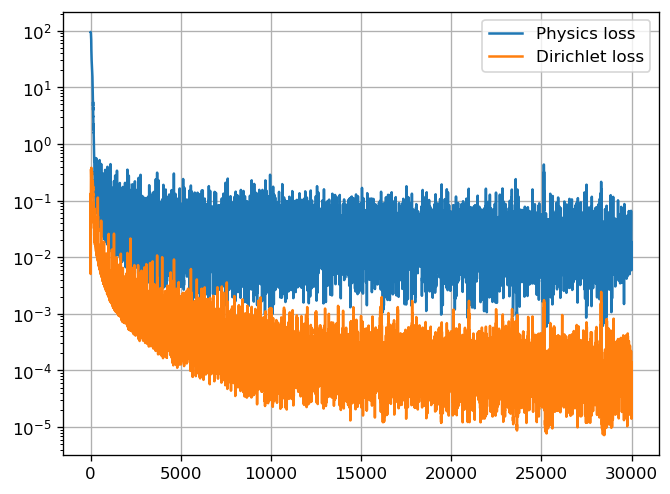

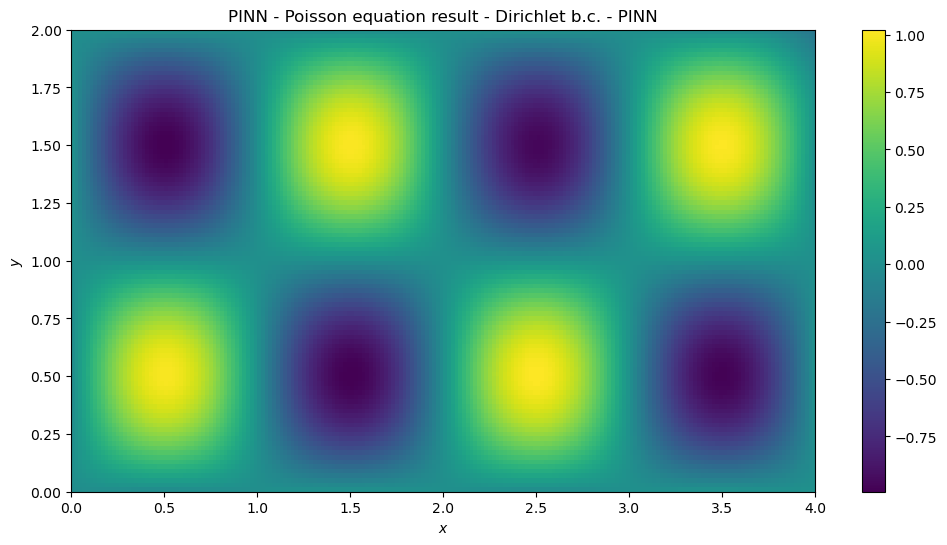

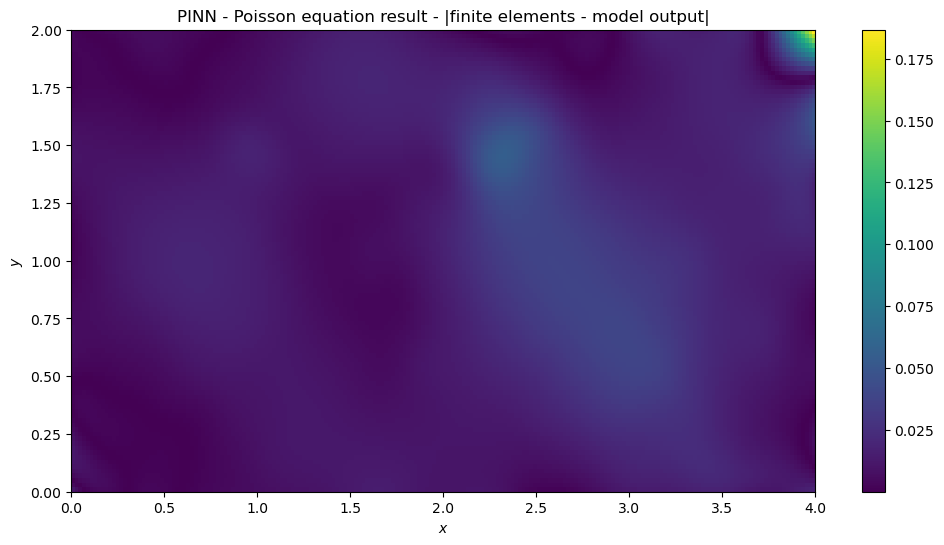

In [5]:

plt.figure(dpi= 120)
plt.semilogy(trial_PINN.epochs, trial_PINN.physics_losses, label = "Physics loss")
plt.semilogy(trial_PINN.epochs, trial_PINN.dirichlet_losses, label = "Dirichlet loss")
plt.grid(True)
plt.legend()
plt.show()

x = np.linspace(0, 4, 200)
y = np.linspace(0, 2, 100)

# build (N, 2) grid points in the same row-major order as imshow expects: shape (len(y), len(x))
X, Y = np.meshgrid(x, y)  # X, Y both shape (100, 200)
grid_points = np.stack([X.ravel(), Y.ravel()], axis=1)  # shape (20000, 2)
grid_points_torch = torch.tensor(grid_points, dtype=torch.float32)

with torch.no_grad():
    u_pred = trial_PINN.model(grid_points_torch)  # shape (20000, 1)

res = u_pred.numpy().reshape(len(y), len(x))  # back to (100, 200) to match X, Y grid

plt.figure(figsize=(12, 6))
plt.imshow(res, cmap='viridis', origin='lower', aspect='auto', extent=[x.min(), x.max(), y.min(), y.max()])
plt.colorbar()
plt.title('PINN - Poisson equation result - Dirichlet b.c. - PINN')
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.savefig('results/poisson_pinn.png')
plt.show()


plt.figure(figsize=(12, 6))
plt.imshow(np.abs(res - res_finite_elements), cmap='viridis', origin='lower', aspect='auto', extent=[x.min(), x.max(), y.min(), y.max()])
plt.colorbar()
plt.title('PINN - Poisson equation result - |finite elements - model output|')
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.savefig('results/difference_FE_PINN_poisson.png')
plt.show()

pretty large values for both losses, especially the physics loss? 

**TO DO: tests varying dimensions and number of collocation and boundary points. When best convergence and overall results?**

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from PINN_3d import *
from FFEM_building_blocks import Mesh
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import spsolve
import matplotlib.pyplot as plt
from matplotlib.animation import FFMpegWriter, FuncAnimation

Mass matrix initialization completed
Stiffness matrix initialization completed
(50, 50)


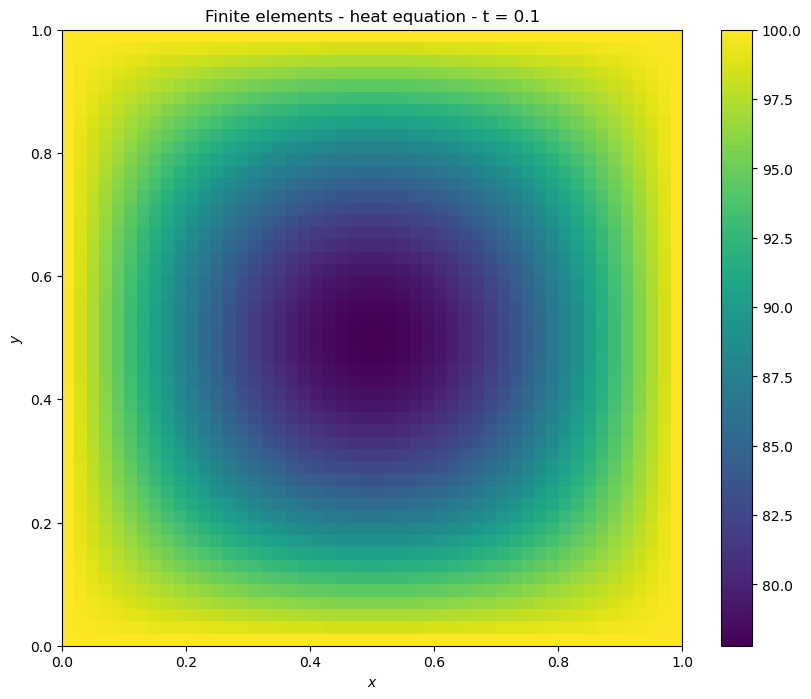

In [5]:
# first, finite elemetn solution for reference
# Implicit midpoint rule (Crank-Nicolson) for time evolution

# grid:
Nx = Ny = 50
x = np.linspace(0, 1, Nx)
y = np.linspace(0, 1, Ny)
u0 = np.zeros(Nx*Ny)
# set initial conditions
for i in [0, Nx-1]:
    for j in range(0, Ny):
                u0[Ny*i + j] = 100
for j in [0, Ny-1]:
    for i in range(1, Nx - 1):
                u0[Ny*i + j] = 100
u = u0.copy()

# prepare the simulation 
mymesh = Mesh(x, y, verbose=True)

steps = 200
times, dt = np.linspace(0, 0.1, steps, retstep = True)
alpha = 1

t_check = 0.1
# Build matrices once before the time loop (expensive to rebuild every step)
mymesh.build_mass_matrix()
mymesh.build_stiffness_matrix()

M = mymesh.M.tocsr()
S = mymesh.S.tocsr()
# Precompute LHS matrix needed for the implicit midpoint rule — it stays constant over the timestep iteration
LHS = (M + (dt * alpha / 2) * S).tolil()

# Apply boundary conditions to LHS once (zero row, set diagonal to 1)
bc_indices = []
for i in [0, Nx - 1]:
    for j in range(0, Ny):
        bc_indices.append(Ny * i + j)
for j in [0, Ny - 1]:
    for i in range(1, Nx - 1):
        bc_indices.append(Ny * i + j)
bc_indices = list(set(bc_indices))
for idx in bc_indices:
    LHS[idx, :] = 0
    LHS[idx, idx] = 1
LHS = LHS.tocsr()  # convert once for efficient solving

for t in times:
    # fompute RHS: (M - dt*alpha/2 * S) * u
    RHS_vec = (M - (dt * alpha / 2) * S).dot(u)

    # apply boundary conditions to RHS
    for idx in bc_indices:
        RHS_vec[idx] = 100

    # finally, solve the linear system
    u = spsolve(LHS, RHS_vec)

res_FE = u.reshape((Nx, Ny)).transpose()
print(np.shape(res_FE))


# plot the results
plt.figure(figsize=(10, 8))
plt.imshow(res_FE, cmap='viridis', origin='lower', aspect='auto', extent=[0, 1, 0, 1])
plt.colorbar()
plt.title(f'Finite elements - heat equation - t = {t_check}')
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.savefig('results/heat_finite_elements.png')
plt.show()

In [9]:
# now try solving the heat equations in 2 spatial dimensions + time 

# initial temperature is 20 inside the geometry (square of side 1), temperature is set to 100 °C on the edge
# work on timespan from 0 to 1
heat_PINN = PINN_heat_2d(16, lambda x: 0, lambda x: 100, (0,1),(0,1), (0,1), alpha = 1)
heat_PINN.set_collocation_points(3000)
heat_PINN.compute_initial_values(1000, 0)
heat_PINN.compute_boundary_values(1000)
heat_PINN.compute_physics_loss()

heat_PINN.train(20000)

Epoch [1000/20000], Loss: 49999.9922
Epoch [2000/20000], Loss: 8060.8276
Epoch [3000/20000], Loss: 1104.5955
Epoch [4000/20000], Loss: 871.2272
Epoch [5000/20000], Loss: 871.4832
Epoch [6000/20000], Loss: 376.8957
Epoch [7000/20000], Loss: 679.2741
Epoch [8000/20000], Loss: 1892.4210
Epoch [9000/20000], Loss: 937.8248
Epoch [10000/20000], Loss: 592.9689
Epoch [11000/20000], Loss: 350.7609
Epoch [12000/20000], Loss: 259.2306
Epoch [13000/20000], Loss: 299.2803
Epoch [14000/20000], Loss: 369.7252
Epoch [15000/20000], Loss: 5605.9922
Epoch [16000/20000], Loss: 3560.6794
Epoch [17000/20000], Loss: 2385.9780
Epoch [18000/20000], Loss: 2056.7764
Epoch [19000/20000], Loss: 1683.6924
Epoch [20000/20000], Loss: 1253.5687


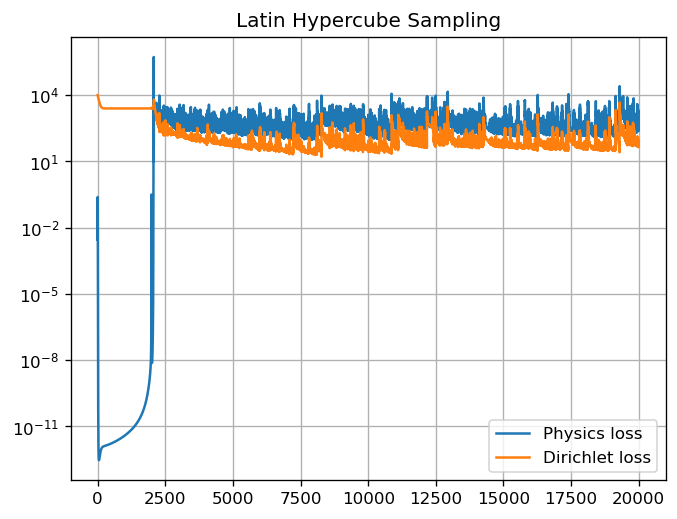

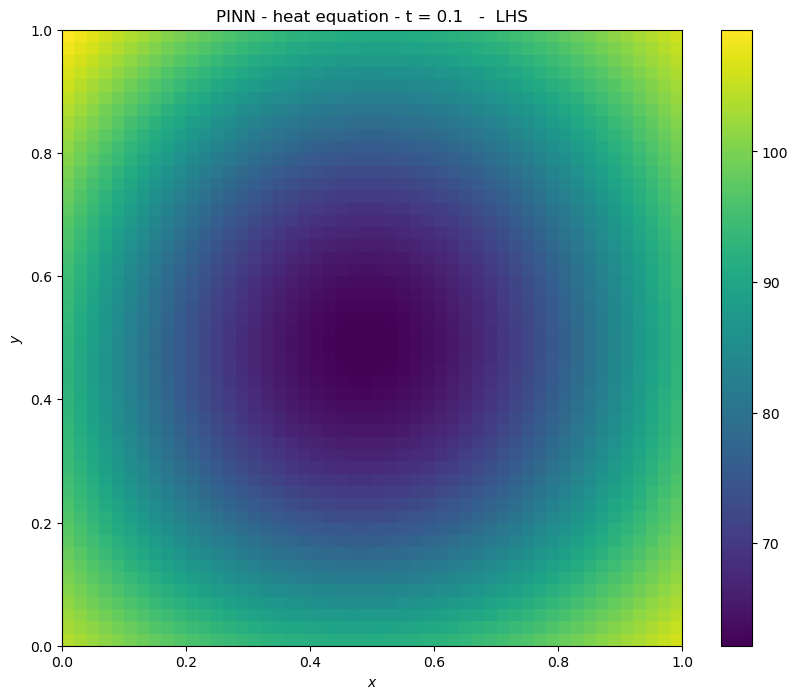

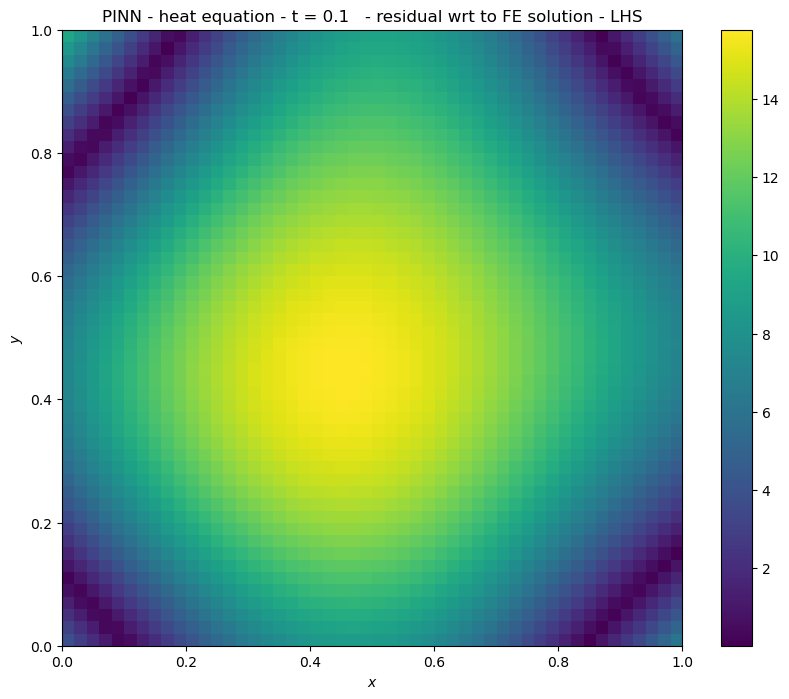

In [ ]:

plt.figure(dpi= 120)
plt.title('Latin Hypercube Sampling')
plt.semilogy(heat_PINN.epochs, heat_PINN.physics_losses, label = "Physics loss")
plt.semilogy(heat_PINN.epochs, heat_PINN.dirichlet_losses, label = "Dirichlet loss")
plt.grid(True)
plt.legend()
plt.show()


t_check = 0.1
x = np.linspace(0, 1, Nx)
y = np.linspace(0, 1, Ny)

# build (N, 2) grid points in the same row-major order as imshow expects: shape (len(y), len(x))
X, Y = np.meshgrid(x, y)  # X, Y both shape (100, 200)
grid_points = np.stack([X.ravel(), Y.ravel(), t_check * np.ones_like(X.ravel())], axis=1)  # shape (..., 2)
grid_points_torch = torch.tensor(grid_points, dtype=torch.float32)
# compute solution at t = 0.1
with torch.no_grad():
    u_pred = heat_PINN.model(grid_points_torch)  # shape (..., 1)

res = u_pred.numpy().reshape(Nx, Ny)  # back to (Nx, Ny) to match X, Y grid

plt.figure(figsize=(10, 8))
plt.imshow(res, cmap='viridis', origin='lower', aspect='auto', extent=[x.min(), x.max(), y.min(), y.max()])
plt.colorbar()
plt.title(f'PINN - heat equation - t = {t_check}   -  LHS')
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.show()


plt.figure(figsize=(10, 8))
plt.imshow(np.abs(res - res_FE), cmap='viridis', origin='lower', aspect='auto', extent=[x.min(), x.max(), y.min(), y.max()])
plt.colorbar()
plt.title(f'PINN - heat equation - t = {t_check}   - residual wrt to FE solution - LHS')
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.show()


In [10]:
# now try training with the RAR-G algorithm (residual-based adaptive finement with greed)

# initial temperature is 20 inside the geometry (square of side 1), temperature is set to 100 °C on the edge
# work on timespan from 0 to 1
heat_PINN = PINN_heat_2d(16, lambda x: 0, lambda x: 100, (0,1),(0,1), (0,1), alpha = 1)
heat_PINN.set_collocation_points(500)
heat_PINN.compute_initial_values(200, 0)
heat_PINN.compute_boundary_values(200)
heat_PINN.compute_physics_loss()

heat_PINN.train_RARG(20000)

Epoch [1000/30000], N_collocation_points: 650, Loss: 49999.9844
Epoch [2000/30000], N_collocation_points: 850, Loss: 5276.7080
Epoch [3000/30000], N_collocation_points: 1050, Loss: 2526.2988
Epoch [4000/30000], N_collocation_points: 1250, Loss: 2147.2029
Epoch [5000/30000], N_collocation_points: 1450, Loss: 1785.8446
Epoch [6000/30000], N_collocation_points: 1650, Loss: 1237.8263
Epoch [7000/30000], N_collocation_points: 1850, Loss: 1499.3320
Epoch [8000/30000], N_collocation_points: 2050, Loss: 1029.4105
Epoch [9000/30000], N_collocation_points: 2250, Loss: 1089.9771
Epoch [10000/30000], N_collocation_points: 2450, Loss: 1086.6729
Epoch [11000/30000], N_collocation_points: 2650, Loss: 917.1731
Epoch [12000/30000], N_collocation_points: 2850, Loss: 858.4366
Epoch [13000/30000], N_collocation_points: 3050, Loss: 955.8587
Epoch [14000/30000], N_collocation_points: 3250, Loss: 959.7782
Epoch [15000/30000], N_collocation_points: 3450, Loss: 1189.1060
Epoch [16000/30000], N_collocation_poin

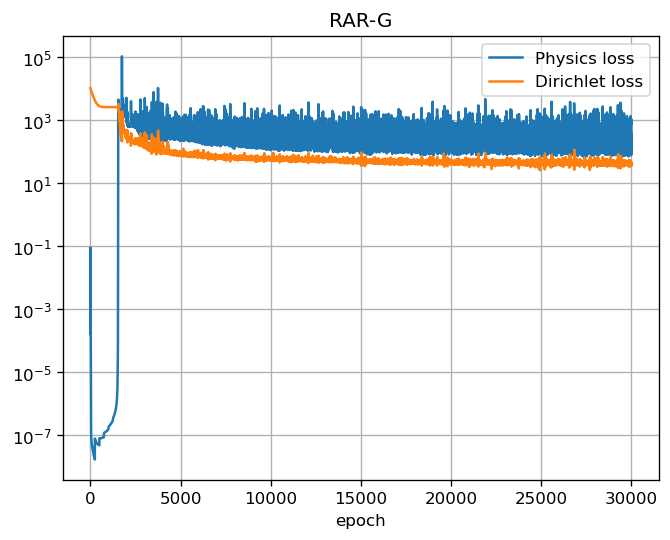

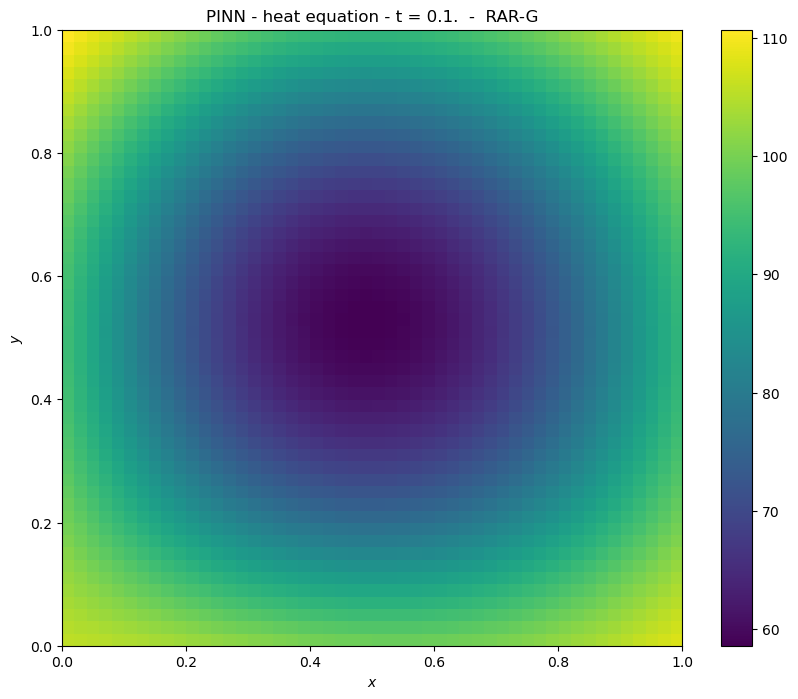

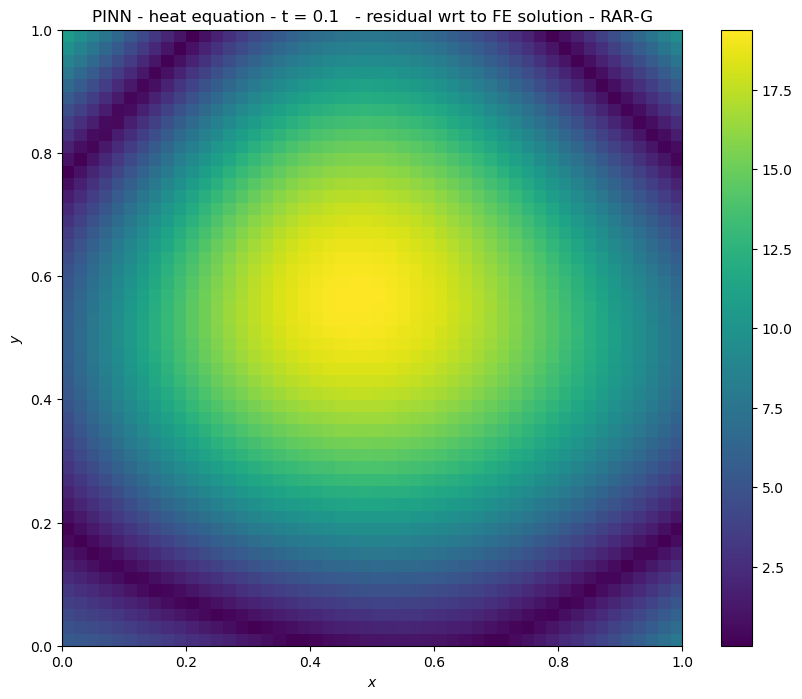

In [11]:
plt.figure(dpi= 120)
plt.title("RAR-G")
plt.xlabel('epoch')
plt.semilogy(heat_PINN.physics_losses, label = "Physics loss")
plt.semilogy(heat_PINN.dirichlet_losses, label = "Dirichlet loss")
plt.grid(True)
plt.legend()
plt.show()

t_check = 0.1

# build (N, 2) grid points in the same row-major order as imshow expects: shape (len(y), len(x))
X, Y = np.meshgrid(x, y)  # X, Y both shape (100, 200)
grid_points = np.stack([X.ravel(), Y.ravel(), t_check * np.ones_like(X.ravel())], axis=1)  # shape (20000, 2)
grid_points_torch = torch.tensor(grid_points, dtype=torch.float32)
# compute solution at t = 1
with torch.no_grad():
    u_pred = heat_PINN.model(grid_points_torch)  # shape (20000, 1)

res = u_pred.numpy().reshape(len(y), len(x))  # back to (100, 200) to match X, Y grid

plt.figure(figsize=(10, 8))
plt.imshow(res, cmap='viridis', origin='lower', aspect='auto', extent=[x.min(), x.max(), y.min(), y.max()])
plt.colorbar()
plt.title(f'PINN - heat equation - t = {t_check}.  -  RAR-G')
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.savefig('results/heat_pinn.png')
plt.show()


plt.figure(figsize=(10, 8))
plt.imshow(np.abs(res - res_FE), cmap='viridis', origin='lower', aspect='auto', extent=[x.min(), x.max(), y.min(), y.max()])
plt.colorbar()
plt.title(f'PINN - heat equation - t = {t_check}   - residual wrt to FE solution - RAR-G')
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.show()

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PINN_3d import *
from FFEM_building_blocks import Mesh
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import spsolve
import matplotlib.pyplot as plt
from matplotlib.animation import FFMpegWriter, FuncAnimation


# now try training with the RAR-G algorithm (residual-based adaptive finement with greed)

# initial temperature is 20 inside the geometry (square of side 1), temperature is set to 100 °C on the edge
# work on timespan from 0 to 1
heat_PINN = PINN_heat_2d(16, lambda x: 0, lambda x: 100, (0,1),(0,1), (0,1), alpha = 1)
heat_PINN.set_collocation_points(500)
heat_PINN.compute_initial_values(200, 0)
heat_PINN.compute_boundary_values(200)
heat_PINN.compute_physics_loss()

heat_PINN.train_RAD(max_epochs = 30000, max_points = 20000)

Epoch [1000/30000], N_collocation_points: 800, Loss: 49999.9961
Epoch [2000/30000], N_collocation_points: 1200, Loss: 10839.9531
Epoch [3000/30000], N_collocation_points: 1600, Loss: 3052.4053
Epoch [4000/30000], N_collocation_points: 2000, Loss: 4712.2495
Epoch [5000/30000], N_collocation_points: 2400, Loss: 2699.8745
Epoch [6000/30000], N_collocation_points: 2800, Loss: 2438.3984
Epoch [7000/30000], N_collocation_points: 3200, Loss: 2402.1086
Epoch [8000/30000], N_collocation_points: 3600, Loss: 1992.7174
Epoch [9000/30000], N_collocation_points: 4000, Loss: 1852.8718
Epoch [10000/30000], N_collocation_points: 4400, Loss: 1732.2734
Epoch [11000/30000], N_collocation_points: 4800, Loss: 1742.8540
Epoch [12000/30000], N_collocation_points: 5200, Loss: 1565.1074
Epoch [13000/30000], N_collocation_points: 5600, Loss: 1674.3969
Epoch [14000/30000], N_collocation_points: 6000, Loss: 1696.9918
Epoch [15000/30000], N_collocation_points: 6400, Loss: 2032.2646
Epoch [16000/30000], N_collocatio

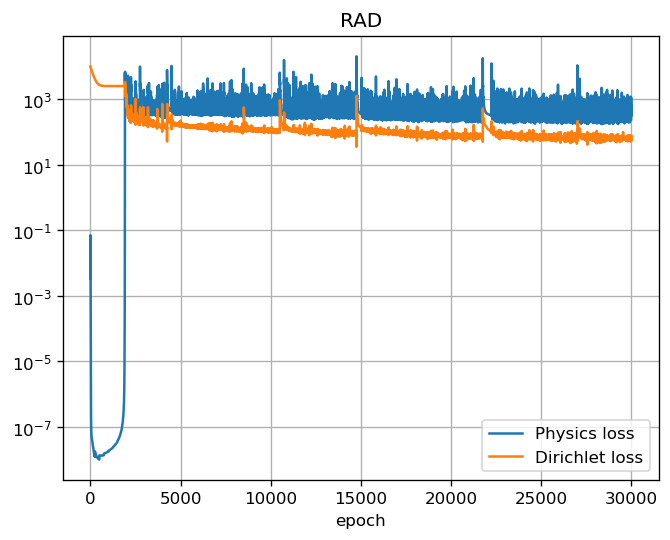

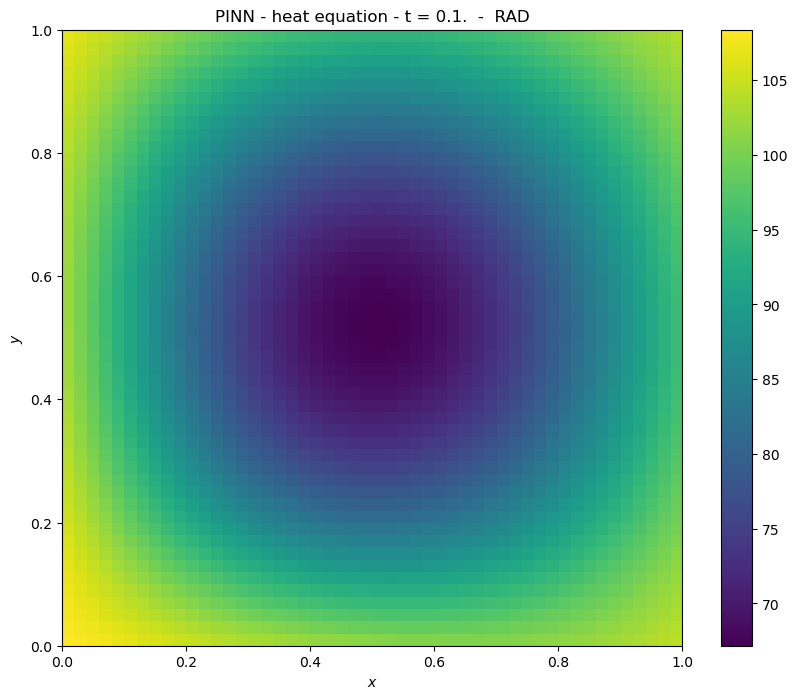

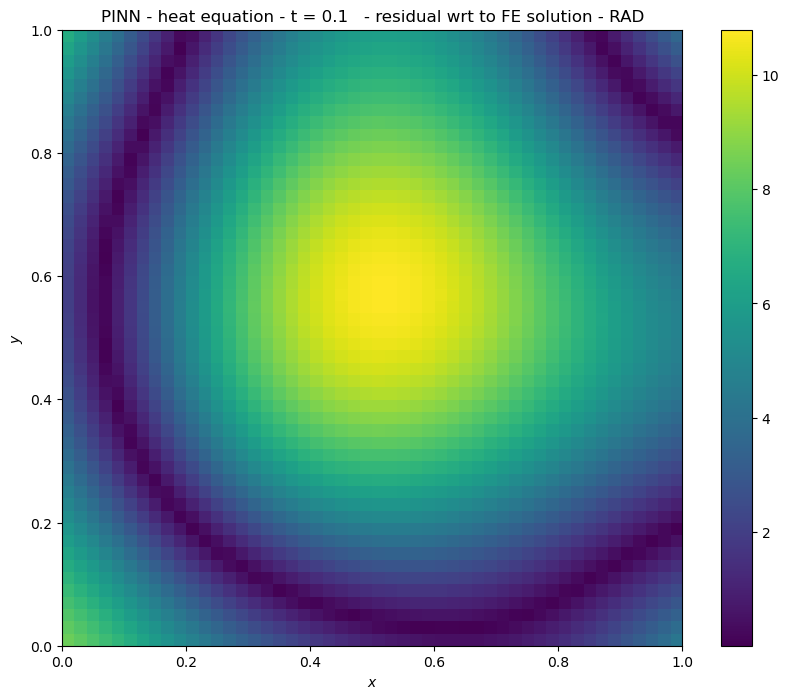

In [6]:
plt.figure(dpi= 120)
plt.title("RAD")
plt.xlabel('epoch')
plt.semilogy(heat_PINN.physics_losses, label = "Physics loss")
plt.semilogy(heat_PINN.dirichlet_losses, label = "Dirichlet loss")
plt.grid(True)
plt.legend()
plt.show()

t_check = 0.1

Nx = Ny = 50
x = np.linspace(0, 1, Nx)
y = np.linspace(0, 1, Ny)
# build (N, 2) grid points in the same row-major order as imshow expects: shape (len(y), len(x))
X, Y = np.meshgrid(x, y)  # X, Y both shape (100, 200)
grid_points = np.stack([X.ravel(), Y.ravel(), t_check * np.ones_like(X.ravel())], axis=1)  # shape (20000, 2)
grid_points_torch = torch.tensor(grid_points, dtype=torch.float32)
# compute solution at t = 1
with torch.no_grad():
    u_pred = heat_PINN.model(grid_points_torch)  # shape (20000, 1)

res = u_pred.numpy().reshape(len(y), len(x))  # back to (100, 200) to match X, Y grid

plt.figure(figsize=(10, 8))
plt.imshow(res, cmap='viridis', origin='lower', aspect='auto', extent=[x.min(), x.max(), y.min(), y.max()])
plt.colorbar()
plt.title(f'PINN - heat equation - t = {t_check}.  -  RAD')
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.savefig('results/heat_pinn.png')
plt.show()


plt.figure(figsize=(10, 8))
plt.imshow(np.abs(res - res_FE), cmap='viridis', origin='lower', aspect='auto', extent=[x.min(), x.max(), y.min(), y.max()])
plt.colorbar()
plt.title(f'PINN - heat equation - t = {t_check}   - residual wrt to FE solution - RAD')
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.show()


**observations**: 
- the temperature in the center of the frame is predicted to be too low. due to influence of initial condition ?
RAR-G seems to show a slightly more stable convergence
- the error is smallest where the gradients of the solution are larger. makes sense, because there the loss will be larger.
- in the center of the frame the gradients are smaller, so the training does not optimize the solution there as much as elsewhere
- the solution obtained with the RAD algorithm seems to have, after the same number of epochs, as slightly smaller max absolute error with respect to the finite volume solution, compared with the two other methods ('vanilla' training, RAR-G). To be checked further.


**things to try**:

Hard-constrain the boundary/initial conditions: my problem is that it seems to converge first to the trivial solution; this is a known problem


**due to the tanh structure it would be best to start with normalized data**. so here this is not a problem anyways, since I am working on the unit square for times smaller than 1. but this is something to keep in mind for future applications.

